### OBESITY LEVEL PREDICTION - ML Project

In [1]:
# 1. Instalar e importar librerias
%pip install ucimlrepo

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from ucimlrepo import fetch_ucirepo
from sklearn.model_selection import train_test_split

Note: you may need to restart the kernel to use updated packages.


In [2]:
# 2. Cargar el dataset
obesity = fetch_ucirepo(id=544) # descarga el dataset directamente de UCI y el id=544 es el identificador del dataset

X = obesity.data.features
y = obesity.data.targets

df = pd.concat([X, y], axis=1) # los pegamos juntas horizontalmente por columnas para ver de forma general el dataframe que tenemos
df.head()

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


De forma general se observa lo siguiente:

- 17 columnas: 16 features y 1 target (NObeyesdad)
- El target tiene categorias como  Normal_Weight, Overweight_Level_I, Overweight_Level_II, etc. Esto es clasificación multiclase (varias categorías)
- Hay columnas númericas (Age, Height, Weight, etc) y categóricas (Gender, CAEC, MTRANS, etc.)

In [3]:
# Renombramos la columna target para mayor claridad
df = df.rename(columns={'NObeyesdad': 'obesity_level'})

In [4]:
# 3. Explorar dataset - shape
df.shape

(2111, 17)

In [5]:
# 4. Explorar tipos de datos y valores nulos
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Gender                          2111 non-null   object 
 1   Age                             2111 non-null   float64
 2   Height                          2111 non-null   float64
 3   Weight                          2111 non-null   float64
 4   family_history_with_overweight  2111 non-null   object 
 5   FAVC                            2111 non-null   object 
 6   FCVC                            2111 non-null   float64
 7   NCP                             2111 non-null   float64
 8   CAEC                            2111 non-null   object 
 9   SMOKE                           2111 non-null   object 
 10  CH2O                            2111 non-null   float64
 11  SCC                             2111 non-null   object 
 12  FAF                             21

Qué encontramos?
- 0 valores nulos en todas las columnas, por lo que no hay que hacer limpieza
- 8 columnas numéricas (float64) y 9 columnas categóricas (object) incluyendo el target

In [6]:
# 5. Comprobamos valores nulos como buena práctica
df.isnull().sum()

Gender                            0
Age                               0
Height                            0
Weight                            0
family_history_with_overweight    0
FAVC                              0
FCVC                              0
NCP                               0
CAEC                              0
SMOKE                             0
CH2O                              0
SCC                               0
FAF                               0
TUE                               0
CALC                              0
MTRANS                            0
obesity_level                     0
dtype: int64

El dataset de Obesity levels de UCI no tiene valores nulos, no es necesario eliminar ni imputar filas.

In [7]:
# 6. Ver la distribución del target
df['obesity_level'].value_counts()

obesity_level
Obesity_Type_I         351
Obesity_Type_III       324
Obesity_Type_II        297
Overweight_Level_I     290
Overweight_Level_II    290
Normal_Weight          287
Insufficient_Weight    272
Name: count, dtype: int64

Vemos que hay 7 clases en el target y revisamos cuántos casos hay en cada una para entender su distribución.

Las clases están bastante balanceadas por ejemplo, la más grande tiene 351 casos (Obesity Type I) y la más pequeña 272 (Insufficient Weight).

A primera vista no hay una clase dominante que pueda distorsionar el modelo.

In [8]:
# 7. Separación features númericas y target
# Usamos solo númericas por ahora, mañana añadiremos las categóricas con enconding

X = df.select_dtypes(include='number')
y = df['obesity_level']

print("Features:", X.columns.tolist())
print("Target:", y.name)

Features: ['Age', 'Height', 'Weight', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE']
Target: obesity_level


Los features númericas son 8:

- Age — edad
- Height — altura
- Weight — peso
- FCVC — frecuencia de consumo de verduras
- NCP — número de comidas principales al día
- CH2O — cantidad de agua que bebe al día
- FAF — frecuencia de actividad física
- TUE — tiempo usando dispositivos tecnológicos

In [9]:
# 8. Train/Test Split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (1688, 8)
Test: (423, 8)


Tenemos lo siguiente: 
- 1.688 filas para entrenar (80%)
- 423 filas para evaluar (20%)

Total = 2.111

Por tanto, se usa la division estandar más utilizada en ML quedando de la siguiente manera:
- El 80% de train (1.688 muestras) da al modelo suficientes datos para aprender los patrones.
- El 20% de test (423 muestras)  para evaluar el modelo de forma fiable.

Se ha usado random_state=0 para que la división sea siempre la misma y los resultados sean reproducibles

In [10]:
# 9. Inicio y training  modelo KNN
from sklearn.neighbors import KNeighborsClassifier 

knn = KNeighborsClassifier() # Classifier porque el target NOeyesdad es una categoría, clasificación multiclase con 7 niveles
knn.fit(X_train, y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [11]:
# 10. Evaluación del modelo
# Se usan varias métricas para evaluar el rendimiento del modelo desde distintas perspectivas

# 10.1 Accuracy (score)
print("Train accuracy:", knn.score(X_train, y_train)) 
print("Test accuracy:", knn.score(X_test, y_test))

Train accuracy: 0.9016587677725119
Test accuracy: 0.8557919621749409


Insights:
- Train: 90.2% → el modelo acierta 9 de cada 10 en entrenamiento
- Test: 85.6% → el modelo acierta 8.5 de cada 10 en datos nuevos

La diferencia es de unos 4.6 puntos (pequeña), no hay overfitting grave. El modelo generaliza bien.

En resumen, se evalu el modelo con .score() que nos devuelve el accuracy (el porcentaje de predicciones correctas sobre el total).
Comparamos train y test accuracy para detectar posibles problemas:
- Si train es muy alto y test muy bajo → overfitting
- Si ambos son similares y razonables → el modelo generaliza bien

En este caso en concreto train (90.2%) y test (85.6%) tienen una diferencia pequeña, lo que indica un buen ajuste.

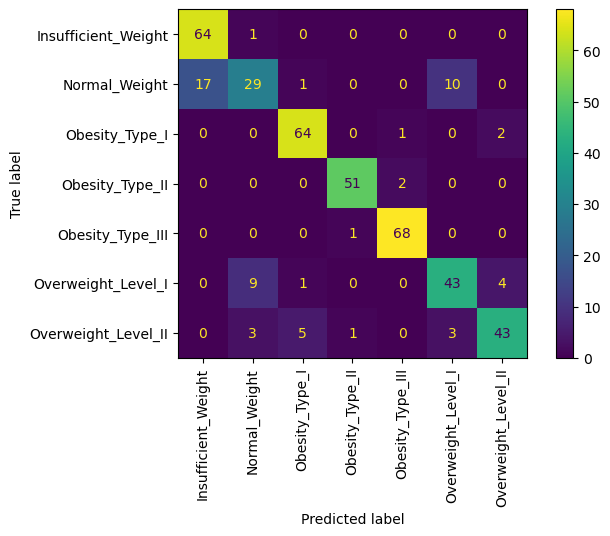

In [12]:
# 10.2 Matriz de confusión

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred = knn.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=knn.classes_)
disp.plot(ax=ax, xticks_rotation=90)
plt.tight_layout(pad=3)
plt.show()



**Interpretación de la matriz de confusión**

La matriz tiene filas = clase real y columnas = clase predicha.
La diagonal son los aciertos, fuera de ella están los errores.

**Destacado:**
- Las clases más extremas (Obesity_Type_III, Obesity_Type_II, Insufficient_Weight) se predicen casi perfectamente.
- Normal_Weight es la clase más difícil, solo acertó 29 de 57 casos.

**¿Por qué?**
Los errores ocurren siempre entre clases cercanas, lo que tiene sentido  es complicado distinguir entre peso normal y sobrepeso leve, incluso con datos.

In [13]:
# 10.3 Classification report

from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

                     precision    recall  f1-score   support

Insufficient_Weight       0.79      0.98      0.88        65
      Normal_Weight       0.69      0.51      0.59        57
     Obesity_Type_I       0.90      0.96      0.93        67
    Obesity_Type_II       0.96      0.96      0.96        53
   Obesity_Type_III       0.96      0.99      0.97        69
 Overweight_Level_I       0.77      0.75      0.76        57
Overweight_Level_II       0.88      0.78      0.83        55

           accuracy                           0.86       423
          macro avg       0.85      0.85      0.84       423
       weighted avg       0.85      0.86      0.85       423



Lo que más destaca del *classification report*:
- Obesity_Type_III → F1 de 0.97 — el modelo lo predice casi perfecto
- Obesity_Type_II → F1 de 0.96 — también bien
- Normal_Weight → F1 de 0.59 — es la clase más difícil, el modelo la confunde bastante con otras


Insight general de las métricas de evaluación:

El modelo obtiene un 85.6% de accuracy global.

Las clases más extremas como Obesity_Type_III (F1: 0.97) y Obesity_Type_II (F1: 0.96) se predicen casi perfectamente.

La clase más difícil es Normal_Weight (F1: 0.59) — el modelo la confunde con clases adyacentes como Insufficient_Weight y Overweight_Level_I, lo cual tiene sentido ya que son categorías limítrofes.

Mañana al añadir las variables categóricas con encoding se espera mejorar especialmente en estas clases intermedias.


In [16]:
# 11. Encoding de variables categóricas

# Miramos qué columnas categóricas tenemos en el dataset

df.select_dtypes(include="object").columns.tolist()

['Gender',
 'family_history_with_overweight',
 'FAVC',
 'CAEC',
 'SMOKE',
 'SCC',
 'CALC',
 'MTRANS',
 'obesity_level']

In [17]:
# Aplicamos encoding excluyendo el target
df_encoded = pd.get_dummies(df, columns=[
    'Gender',
    'family_history_with_overweight',
    'FAVC',
    'CAEC',
    'SMOKE',
    'SCC',
    'CALC',
    'MTRANS'
], dtype=int)

df_encoded.shape

(2111, 32)

In [19]:
df_encoded

,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE,obesity_level,Gender_Female,...,SCC_yes,CALC_Always,CALC_Frequently,CALC_Sometimes,CALC_no,MTRANS_Automobile,MTRANS_Bike,MTRANS_Motorbike,MTRANS_Public_Transportation,MTRANS_Walking
0,21.000000,1.620000,64.000000,2.0,3.0,2.000000,0.000000,1.000000,Normal_Weight,1,...,0,0,0,0,1,0,0,0,1,0
1,21.000000,1.520000,56.000000,3.0,3.0,3.000000,3.000000,0.000000,Normal_Weight,1,...,1,0,0,1,0,0,0,0,1,0
2,23.000000,1.800000,77.000000,2.0,3.0,2.000000,2.000000,1.000000,Normal_Weight,0,...,0,0,1,0,0,0,0,0,1,0
3,27.000000,1.800000,87.000000,3.0,3.0,2.000000,2.000000,0.000000,Overweight_Level_I,0,...,0,0,1,0,0,0,0,0,0,1
4,22.000000,1.780000,89.800000,2.0,1.0,2.000000,0.000000,0.000000,Overweight_Level_II,0,...,0,0,0,1,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2106,20.976842,1.710730,131.408528,3.0,3.0,1.728139,1.676269,0.906247,Obesity_Type_III,1,...,0,0,0,1,0,0,0,0,1,0
2107,21.982942,1.748584,133.742943,3.0,3.0,2.005130,1.341390,0.599270,Obesity_Type_III,1,...,0,0,0,1,0,0,0,0,1,0
2108,22.524036,1.752206,133.689352,3.0,3.0,2.054193,1.414209,0.646288,Obesity_Type_III,1,...,0,0,0,1,0,0,0,0,1,0
2109,24.361936,1.739450,133.346641,3.0,3.0,2.852339,1.139107,0.586035,Obesity_Type_III,1,...,0,0,0,1,0,0,0,0,1,0


Tras aplicar el One-Hot Enconding se pasó de 17 columnas a 32. Las 8 categorías se expandieron en multiples columnas dummy.

Sin embargo, obesity_level sigue como object y no ha cambiado.

Por tanto, con el encoding se ha incluido las variables categórics como features y esto no se podía hacer antes de enconding porque KNN no entiende texto.

Sin el encoding, X tenía 8 columnas (solo númericas) y se descartaba toda la info de Gender, CAEC, MTRANS, etc.

Ahora con el encoding, X tiene 31 columnas (las 8 númericas + las categóricas convertidas a números). Por lo tanto, el modelo ahora puede aprender/entrenar de las categóricas ahora númericas como por ejemplo, de si alguien es hombre o mujer, el transporta que usa, si fuma, etc.

In [ ]:
# 12. Separación features y target con encoding
X = df_encoded.drop(columns=["obesity_level"])
y = df_encoded["obesity_level"]

# 13. Train/Test split con encoding
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)
print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (1688, 31)
Test: (423, 31)


Tras enconding tenemos lo siguiente:
- 1.688 filas para train (80%)
- 423 filas para test (20%)
TOTAL = 2.111

Ahora hay 31 features en lugar de 8 sin el enconding.

In [35]:
# 14. Normalización  con StandardScaler
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Recuperación nombres de columnas
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

X_train_scaled


,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE,Gender_Female,Gender_Male,...,SCC_yes,CALC_Always,CALC_Frequently,CALC_Sometimes,CALC_no,MTRANS_Automobile,MTRANS_Bike,MTRANS_Motorbike,MTRANS_Public_Transportation,MTRANS_Walking
0,2.184846,-1.557814,-0.281859,-0.777372,0.401761,-1.209898,-1.192593,-1.089561,1.038662,-1.038662,...,-0.220107,-0.024347,-0.190312,0.704595,-0.648749,1.903853,-0.064531,-0.069007,-1.715787,-0.17108
1,2.535554,0.194567,0.856293,-0.248314,1.386978,-1.659272,0.367097,-1.089561,-0.962778,0.962778,...,-0.220107,-0.024347,-0.190312,-1.419255,1.541428,1.903853,-0.064531,-0.069007,-1.715787,-0.17108
2,2.422106,-1.398289,-0.265572,-0.642985,0.373509,-0.893405,-1.192593,-1.089561,1.038662,-1.038662,...,-0.220107,-0.024347,-0.190312,-1.419255,1.541428,1.903853,-0.064531,-0.069007,-1.715787,-0.17108
3,-0.173598,0.605672,0.414652,-0.777372,0.401761,1.593224,1.655864,2.178027,-0.962778,0.962778,...,-0.220107,-0.024347,-0.190312,-1.419255,1.541428,-0.525251,-0.064531,-0.069007,0.582823,-0.17108
4,-0.282730,0.195259,-1.346904,0.467431,0.401761,-1.592039,-0.261362,1.209840,1.038662,-1.038662,...,-0.220107,-0.024347,-0.190312,-1.419255,1.541428,-0.525251,-0.064531,-0.069007,0.582823,-0.17108
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1683,-0.737514,-0.049485,-0.345565,-0.917977,-0.418895,1.242051,-1.192593,-0.868919,-0.962778,0.962778,...,-0.220107,-0.024347,-0.190312,-1.419255,1.541428,-0.525251,-0.064531,-0.069007,0.582823,-0.17108
1684,0.983779,0.798682,1.287669,0.482099,0.401761,0.213897,-0.157845,-0.108452,-0.962778,0.962778,...,-0.220107,-0.024347,-0.190312,0.704595,-0.648749,1.903853,-0.064531,-0.069007,-1.715787,-0.17108
1685,-0.527455,-0.895651,-0.652268,-0.777372,-2.155987,1.611588,-0.020351,-1.089561,-0.962778,0.962778,...,-0.220107,-0.024347,-0.190312,0.704595,-0.648749,-0.525251,-0.064531,-0.069007,0.582823,-0.17108
1686,0.788516,-0.656028,-0.655845,-0.088851,0.401761,-0.143920,0.661005,-1.089561,1.038662,-1.038662,...,-0.220107,-0.024347,-0.190312,0.704595,-0.648749,1.903853,-0.064531,-0.069007,-1.715787,-0.17108


Teniendo en cuenta el dataset de obesidad se utiliza StandardScaler para normalizar las features porque:
- Hay columnas con rangos distintos como Weight que puede ir de 30 a 170kg y Age 
- Las columnas dummy 0/1 son muchas 
- Es un problema de clasificación multiclase
- Es más robusto frente a valores extremos (outlier)s que MinMaxScaler.

Tras normalización, todos los valores están en escalas similares, hay números positivos y negativos cercanos a 0, en vez de rangos ta dispares como antes (Age 16-80, Weight 30-170, columnas dummy 0-1). 

Recordatorio: StandardScaler transforma cada columna para que tenga media 0 y desviación estándar 1:
- Valores por encima de la media → positivos
- Valores por debajo de la media → negativos
- El valor exacto de la media → 0

Los negativos NO significan valores negativos reales. Significan: valor está por debajo de la media del grupo.

Ejemplo con Weight (media = 85kg):
- Persona de 90kg → valor positivo (+0.3)
- Persona de 60kg → valor negativo (-1.5)

La información original sigue intacta, solo cambia la escala

Nota personal: normalizar no elimina la información del peso, solo cambia su escala. Normalizar pone a todas las features en igualdad de condiciones para que el modelo valore a cada una según importancia real.


In [36]:
# 15. Balance

# Comprobamos distribución del target
y.value_counts()

obesity_level
Obesity_Type_I         351
Obesity_Type_III       324
Obesity_Type_II        297
Overweight_Level_I     290
Overweight_Level_II    290
Normal_Weight          287
Insufficient_Weight    272
Name: count, dtype: int64

Como ya vimos al inicio del proyecto en el punto # 6., el dataset está bien balanceado, la clase más grande tiene 351 casos y la más pequeña 272. Por tanto, no es necesario aplicar técnicas de balanceo como omo Oversampling, Undersampling o SMOTE.

Aplicarlas en un dataset ya balanceado podría distorsionar el modelo sin ningún beneficio

In [37]:
# 16. Reentrenar KNN y comparar resultados
knn = KNeighborsClassifier()
knn.fit(X_train_scaled, y_train)

print("Train accuracy:", knn.score(X_train_scaled, y_train))
print("Test accuracy:", knn.score(X_test_scaled, y_test))

Train accuracy: 0.8572274881516587
Test accuracy: 0.7990543735224587


| | Train | Test |
|--|--|--|
| **Ayer** (8 features numéricas, sin escalar) | 90.2% | 85.6% |
| **Hoy** (31 features con encoding + scaling) | 85.7% | 79.9% |

Añadiendo encoding y normalización el modelo empeora ligeramente (79.9% vs 85.6%).
Esto puede deberse a que con 31 features algunas columnas dummy pueden estar 
añadiendo ruido en vez de información útil para KNN.
El siguiente paso es aplicar selección de features para mejorar el modelo.


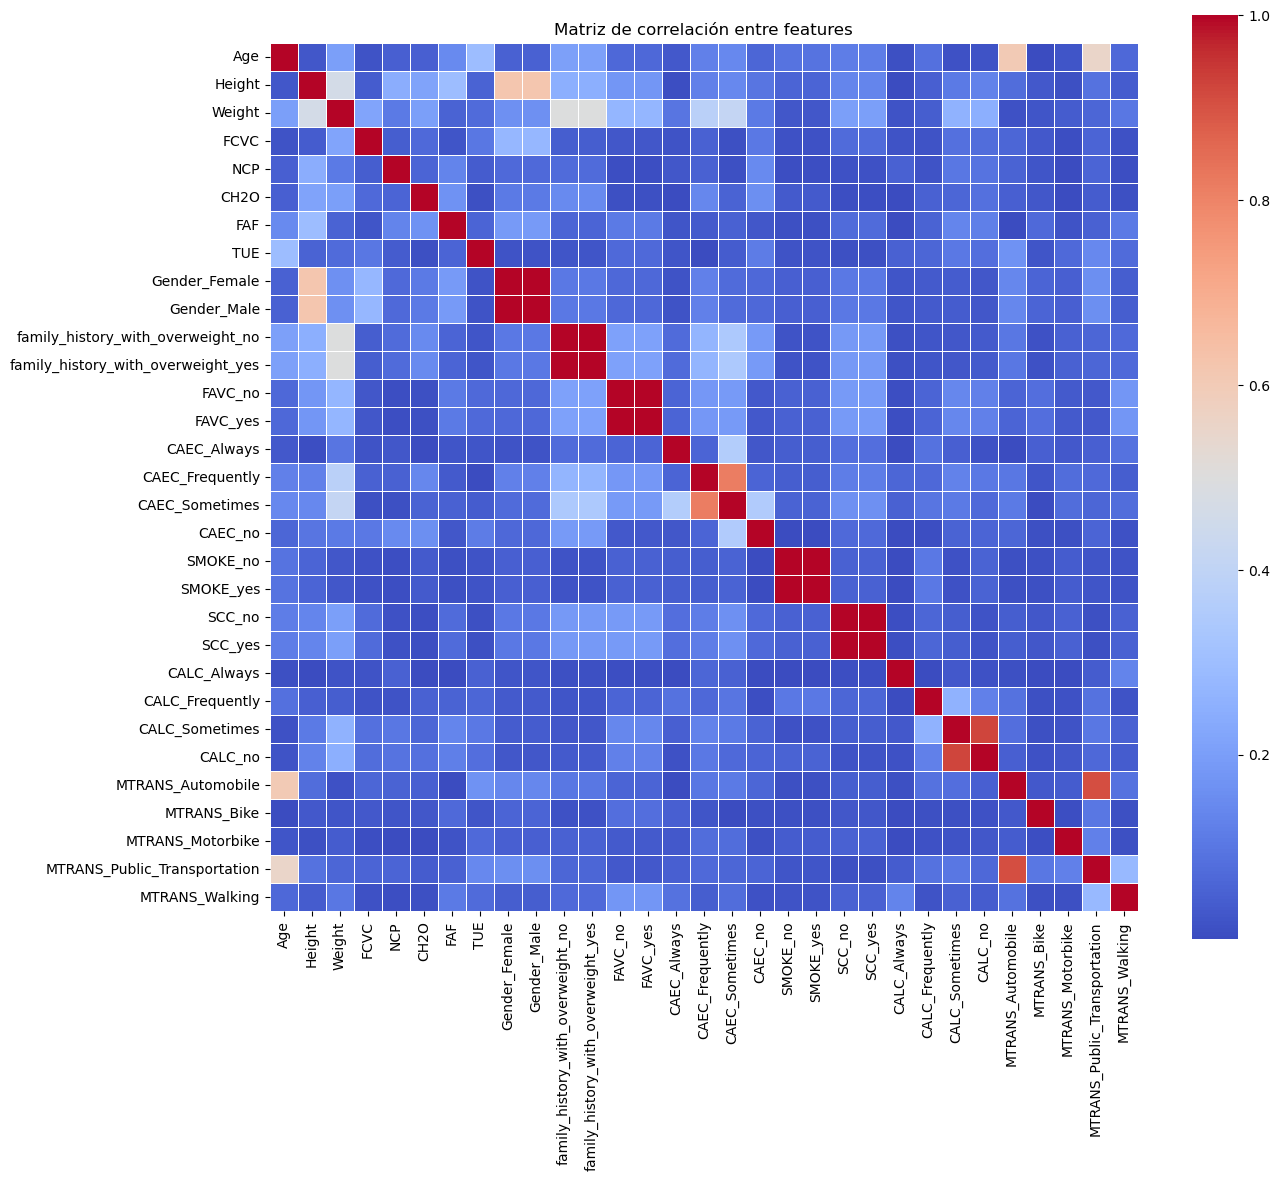

In [38]:
# 17. Matriz de correlación
import seaborn as sns

corr = df_encoded.drop(columns=["obesity_level"]).corr().abs()

plt.figure(figsize=(14, 12))
sns.heatmap(corr, vmax=1, square=True, linewidths=.5, cmap="coolwarm")
plt.title("Matriz de correlación entre features")
plt.show()

Cada variable categórica está muy correlacionada con su opuesta lo que es lógico y esperado porque son columnas dummy:

- Gender_Female y Gender_Male → correlación 1.0 (son exactamente opuestas)
- SMOKE_no y SMOKE_yes → correlación 1.0
- SCC_no y SCC_yes → correlación 1.0
- FAVC_no y FAVC_yes → correlación 1.0
- family_history_with_overweight_no y _yes → correlación 1.0

Esto es información innecesaria si se sabe que Gender_Female = 1, automáticamente se sabe que Gender_Male = 0. No se necesita las dos.
La solución: quedarnos solo con UNA columna de cada par

In [41]:
# 18. Eliminar columnas innecesarias (una de cada par dummy)
df_encoded = pd.get_dummies(df, columns=[
    'Gender',
    'family_history_with_overweight',
    'FAVC',
    'CAEC',
    'SMOKE',
    'SCC',
    'CALC',
    'MTRANS'
], dtype=int, drop_first=True)

df_encoded.shape

(2111, 24)

De 32 columnas pasamos a 24 columnas, se han eliminado 8 columnas innecesarias. Ahora repetiremos el split, normalizacion reentreno del modelo con estas 23 features (24 -1 del target) y crearemos una función porque estos pasos se repiten.

In [44]:
# Creamos función reutilizable para que haga el split, normalización y train todo a la vez
def entrenar_knn(df, target_col, test_size=0.2, random_state=0):
    # Separar features y target
    X = df.drop(columns=[target_col])
    y = df[target_col]
    
    # Train/Test Split
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=random_state)
    
    # Normalización
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
    X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)
    
    # Entrenar KNN
    knn = KNeighborsClassifier()
    knn.fit(X_train_scaled, y_train)
    
    print("Train accuracy:", knn.score(X_train_scaled, y_train))
    print("Test accuracy:", knn.score(X_test_scaled, y_test))
    
    return knn, X_train_scaled, X_test_scaled, y_train, y_test

In [45]:
knn, X_train_scaled, X_test_scaled, y_train, y_test = entrenar_knn(df_encoded, "obesity_level")

Train accuracy: 0.8554502369668247
Test accuracy: 0.8108747044917257


Resumen de lo hecho hasta ahora

| | Train | Test |
|--|--|--|
| **Modelo base** (8 features numéricas, sin escalar) | 90.2% | 85.6% |
| **Con encoding + scaling** (31 features) | 85.7% | 79.9% |
| **Con encoding + scaling + selección de features** (23 features) | 85.5% | 81.1% |

El mejor modelo hasta ahora sigue siendo el modelo base con 85.6% en test.

Mañana, con la nueva clase de ML que haya se intentará superarlo
